# Bright-Field (BF) and Dark-Field (DF) Image Fusion Processing 

# 1. Importing Required Libraries
Dependencies and Environment Configuration

In [1]:
import cv2
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. Path and Parameter Configuration

In [2]:
# Path Configuration
PROJECT_ROOT = os.path.dirname(os.path.abspath("__file__"))
INPUT_DIR = os.path.join(PROJECT_ROOT, "Dimage")
MASK_DIR = os.path.join(PROJECT_ROOT, "masks")
ABC_DIR = os.path.join(PROJECT_ROOT, "Bimage")
MASKS2_DIR = os.path.join(PROJECT_ROOT, "masks2")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "process_result")

# Configurable Parameters
BLUE_THRESHOLD = 80  # Binarization Threshold
CLIP_LIMIT = 3.0     # CLAHE Contrast Limit
TILE_GRID_SIZE = (8, 8)  # CLAHE Tile Grid Size

# Creating Output Directories
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Selecting a Random Input Image
input_images = glob.glob(os.path.join(INPUT_DIR, "*.jpeg"))
if not input_images:
    raise FileNotFoundError(f"No JPEG images found in the {INPUT_DIR} directory")
target_img_path = random.choice(input_images)
filename = os.path.splitext(os.path.basename(target_img_path))[0]
print(f"Processing image: {filename}.jpeg")

Processing image: 2.jpeg


# 3. RGB Channel Separation

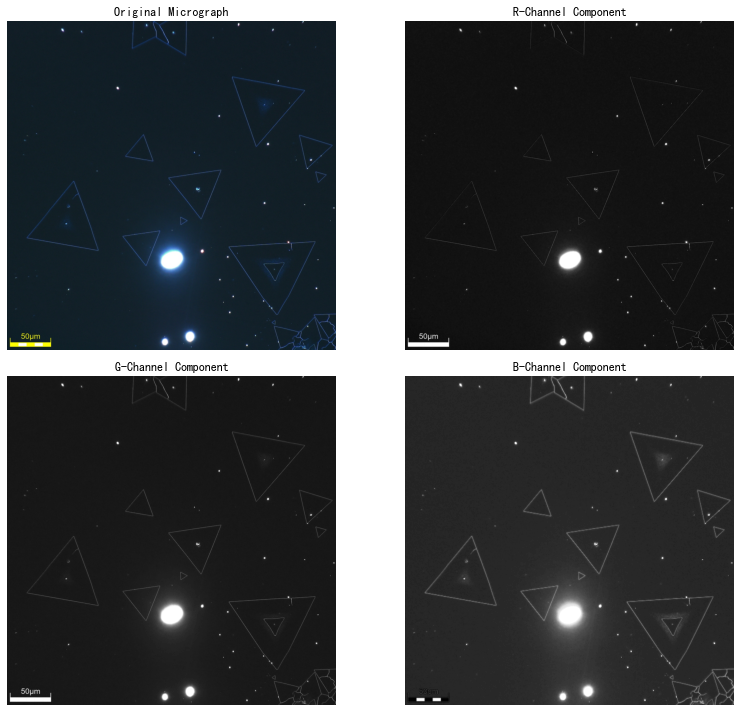

True

In [3]:
# Loading the Micrograph
img = cv2.imread(target_img_path)
if img is None:
    raise ValueError(f"Error: Unable to read image: {target_img_path}")

# BGR Channel Decomposition
blue_channel, green_channel, red_channel = cv2.split(img)

# Visualization of the Original Micrograph and Individual Channels
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Original Micrograph")
axes[0, 0].axis("off")

axes[0, 1].imshow(red_channel, cmap="gray")
axes[0, 1].set_title("R-Channel Component")
axes[0, 1].axis("off")

axes[1, 0].imshow(green_channel, cmap="gray")
axes[1, 0].set_title("G-Channel Component")
axes[1, 0].axis("off")

axes[1, 1].imshow(blue_channel, cmap="gray")
axes[1, 1].set_title("B-Channel Component")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

#Saving the Isolated Color Channels
channel_dir = os.path.join(OUTPUT_DIR, "output_channels")
os.makedirs(channel_dir, exist_ok=True)
cv2.imwrite(os.path.join(channel_dir, f"{filename}_red_channel.jpg"), red_channel)
cv2.imwrite(os.path.join(channel_dir, f"{filename}_green_channel.jpg"), green_channel)
cv2.imwrite(os.path.join(channel_dir, f"{filename}_blue_original.jpg"), blue_channel)

# 4.Blue Channel Contrast Enhancement via CLAHE

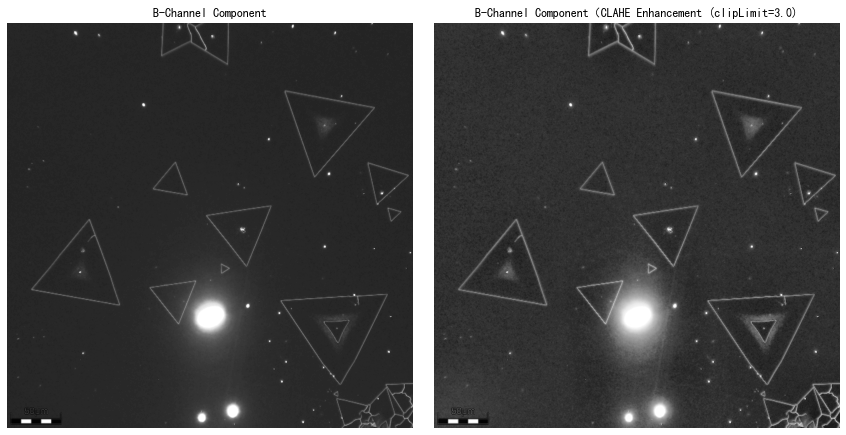

True

In [4]:
# Creating the CLAHE Object and Enhancing the Blue Channel
clahe = cv2.createCLAHE(clipLimit=CLIP_LIMIT, tileGridSize=TILE_GRID_SIZE)
blue_enhanced = clahe.apply(blue_channel)

# Comparison of the Blue Channel Before and After Enhancement
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(blue_channel, cmap="gray")
axes[0].set_title("B-Channel Component")
axes[0].axis("off")

axes[1].imshow(blue_enhanced, cmap="gray")
axes[1].set_title(f"B-Channel Component（CLAHE Enhancement (clipLimit={CLIP_LIMIT})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Saving the Enhanced Blue Channel
cv2.imwrite(os.path.join(channel_dir, f"{filename}_blue_enhanced.jpg"), blue_enhanced)

# 5. Blue Channel Binarization

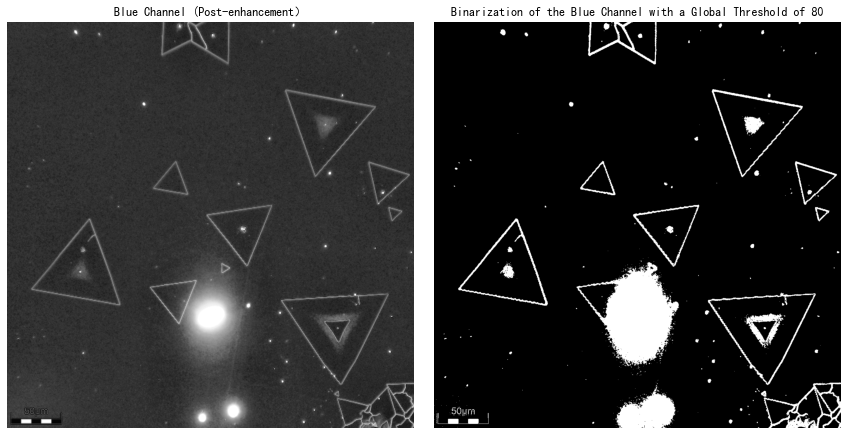

True

In [5]:
#Binarization of the Enhanced Blue Channel
_, blue_binary = cv2.threshold(blue_enhanced, BLUE_THRESHOLD, 255, cv2.THRESH_BINARY)

# Visualization of Binarization Results
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(blue_enhanced, cmap="gray")
axes[0].set_title("Blue Channel (Post-enhancement）")
axes[0].axis("off")

axes[1].imshow(blue_binary, cmap="gray")
axes[1].set_title(f"Binarization of the Blue Channel with a Global Threshold of {BLUE_THRESHOLD}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#Saving the Binarization Results
cv2.imwrite(os.path.join(channel_dir, f"{filename}_blue_binary.jpg"), blue_binary)

# 6.Hole Filling

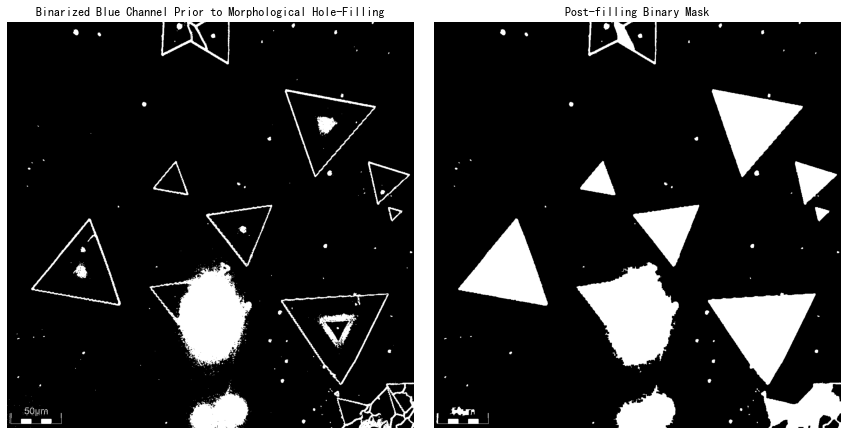

True

In [6]:
def robust_fill_white_contours(binary_image):
    """Improved Contour Filling Function"""
    kernel = np.ones((5, 5), np.uint8)
    binary = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, kernel, iterations=1)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(binary)
    for cnt in contours:
        if cv2.contourArea(cnt) > 4:
            cv2.drawContours(filled, [cnt], -1, 255, cv2.FILLED)
    filled = cv2.morphologyEx(filled, cv2.MORPH_CLOSE, kernel)
    return filled

# Execute Contour Filling
filled_img = robust_fill_white_contours(blue_binary)

# Comparison Before and After Contour Filling
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(blue_binary, cmap="gray")
axes[0].set_title("Binarized Blue Channel Prior to Morphological Hole-Filling")
axes[0].axis("off")

axes[1].imshow(filled_img, cmap="gray")
axes[1].set_title("Post-filling Binary Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#Saving the Refined Segmentation Output
filled_dir = os.path.join(OUTPUT_DIR, "filled_results")
os.makedirs(filled_dir, exist_ok=True)
cv2.imwrite(os.path.join(filled_dir, f"{filename}_filled.png"), filled_img)

# 7.Mask Alignment and Bitwise AND Operation

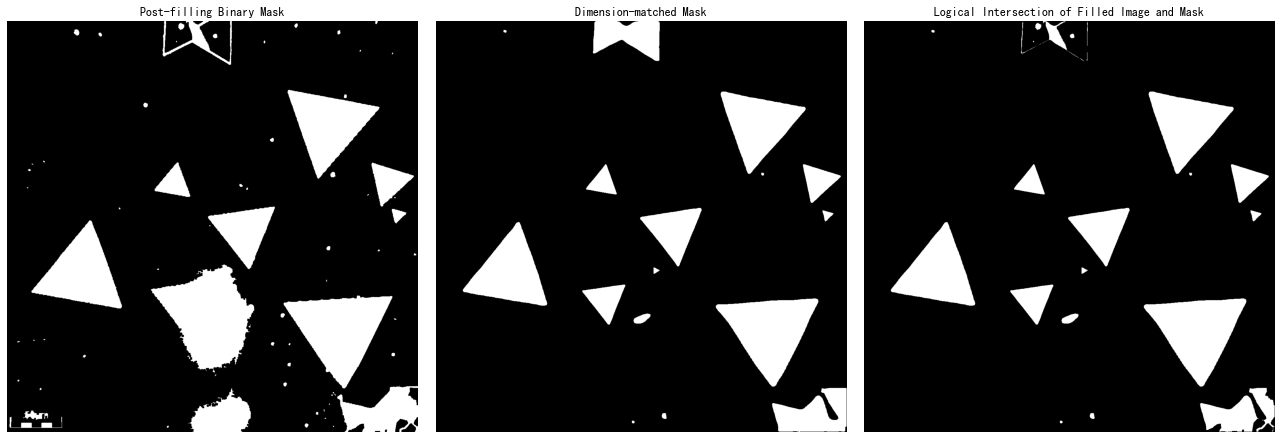

In [7]:
# Importing the Associated Binary Masks
mask_path = os.path.join(MASK_DIR, f"mask_{filename}.png")
alt_mask_path = os.path.join(MASK_DIR, f"{filename}_mask.png")
if not os.path.exists(mask_path) and os.path.exists(alt_mask_path):
    mask_path = alt_mask_path
if not os.path.exists(mask_path):
    raise FileNotFoundError(f"Error: Corresponding mask file not found at {mask_path}")

mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
if mask_img is None:
    raise ValueError(f"Failed to read mask file: {mask_path}")

# Resizing the Mask to Match the Filled Image
if filled_img.shape != mask_img.shape:
    print(f"Resizing mask: {mask_img.shape} -> {filled_img.shape}")
    mask_img = cv2.resize(mask_img, (filled_img.shape[1], filled_img.shape[0]), interpolation=cv2.INTER_NEAREST)

# Binary Segmentation
_, binary_filled = cv2.threshold(filled_img, 127, 255, cv2.THRESH_BINARY)
_, binary_mask = cv2.threshold(mask_img, 127, 255, cv2.THRESH_BINARY)

# Performing Logical AND on Binary Masks
result = cv2.bitwise_and(binary_filled, binary_mask)

# Comparison: Individual Masks vs. Fused Bitwise Result
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(binary_filled, cmap="gray")
axes[0].set_title("Post-filling Binary Mask")
axes[0].axis("off")

axes[1].imshow(binary_mask, cmap="gray")
axes[1].set_title("Dimension-matched Mask")
axes[1].axis("off")

axes[2].imshow(result, cmap="gray")
axes[2].set_title("Logical Intersection of Filled Image and Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# 8.Excluding White Regions of the Blue Channel and Displaying Final Result

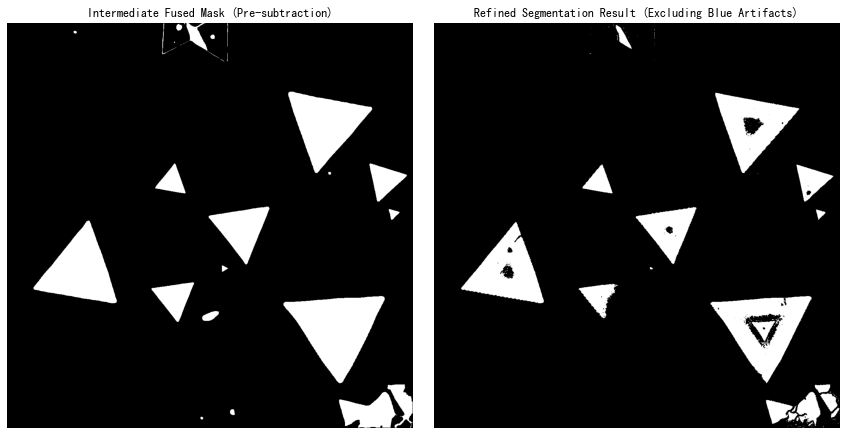

Final result saved to: C:\Users\31227\Desktop\MoS2_Mask Rcnn\process_result\final_results\2_result.png


In [9]:
# Adjusting the Dimensions of the Blue Mask
if blue_binary.shape != result.shape:
    blue_binary = cv2.resize(blue_binary, (result.shape[1], result.shape[0]), interpolation=cv2.INTER_NEAREST)

# Bitwise NOT followed by Bitwise AND
blue_binary_inv = cv2.bitwise_not(blue_binary)
result_subtracted = cv2.bitwise_and(result, blue_binary_inv)

# Displaying the Final Results
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(result, cmap="gray")
axes[0].set_title("Intermediate Fused Mask (Pre-subtraction)")
axes[0].axis("off")

axes[1].imshow(result_subtracted, cmap="gray")
axes[1].set_title("Refined Segmentation Result (Excluding Blue Artifacts)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#Exporting Final Segmentation Masks
final_dir = os.path.join(OUTPUT_DIR, "final_results")
os.makedirs(final_dir, exist_ok=True)
result_path = os.path.join(final_dir, f"{filename}_result.png")
cv2.imwrite(result_path, result_subtracted)
print(f"Final result saved to: {result_path}")

# 9.Computing the Difference with Masks2 and Visualization

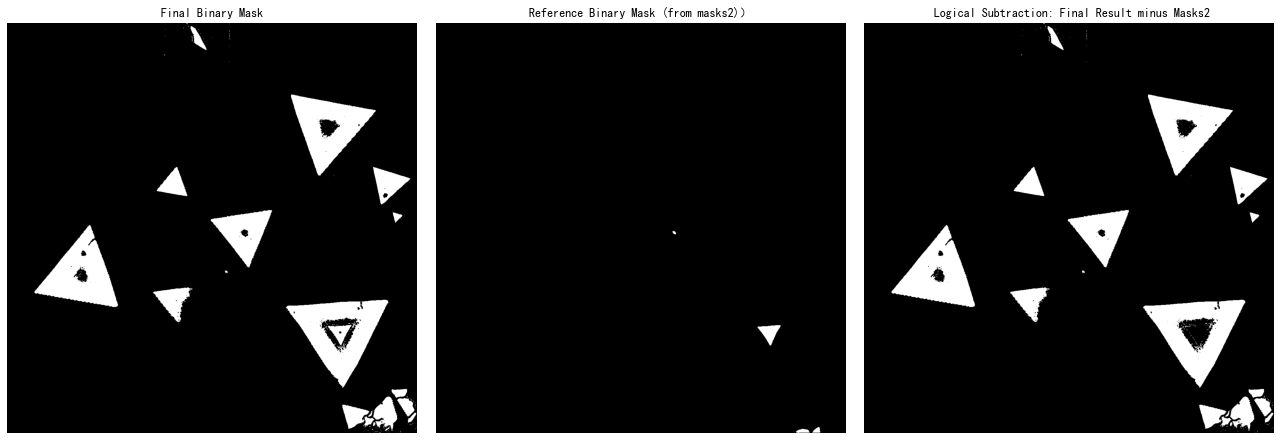

Difference result saved to: C:\Users\31227\Desktop\MoS2_Mask Rcnn\process_result\subtracted_results\2_subtracted.png


In [11]:
def subtract_single_image(final_result_path, mask2_dir, output_dir):
    """Pixel-wise Subtraction for Individual Micrographs"""
    os.makedirs(output_dir, exist_ok=True)
    filename = os.path.basename(final_result_path)
    base_name = filename.replace("_result.png", "")
    
    mask2_path = os.path.join(mask2_dir, f"mask_{base_name}.png")
    if not os.path.exists(mask2_path):
        raise FileNotFoundError(f"Error: Corresponding file not found in 'masks2' at {mask2_path}")
    
    final_result_img = cv2.imread(final_result_path, cv2.IMREAD_GRAYSCALE)
    mask2_img = cv2.imread(mask2_path, cv2.IMREAD_GRAYSCALE)
    
    if final_result_img.shape != mask2_img.shape:
        print(f"Resizing mask2: {mask2_img.shape} -> {final_result_img.shape}")
        mask2_img = cv2.resize(mask2_img, (final_result_img.shape[1], final_result_img.shape[0]), interpolation=cv2.INTER_NEAREST)
    
    _, final_result_binary = cv2.threshold(final_result_img, 127, 255, cv2.THRESH_BINARY)
    _, mask2_binary = cv2.threshold(mask2_img, 127, 255, cv2.THRESH_BINARY)
    
    mask2_inv = cv2.bitwise_not(mask2_binary)
    subtracted_result = cv2.bitwise_and(final_result_binary, mask2_inv)
    
    output_path = os.path.join(output_dir, f"{base_name}_subtracted.png")
    cv2.imwrite(output_path, subtracted_result)
    return subtracted_result, mask2_binary, final_result_binary

#Executing the Difference Calculation
subtracted_dir = os.path.join(OUTPUT_DIR, "subtracted_results")
subtracted_result, mask2_binary, final_result_binary = subtract_single_image(result_path, MASKS2_DIR, subtracted_dir)

# Displaying the Difference Results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(final_result_binary, cmap="gray")
axes[0].set_title("Final Binary Mask")
axes[0].axis("off")

axes[1].imshow(mask2_binary, cmap="gray")
axes[1].set_title("Reference Binary Mask (from masks2)）")
axes[1].axis("off")

axes[2].imshow(subtracted_result, cmap="gray")
axes[2].set_title(" Logical Subtraction: Final Result minus Masks2")
axes[2].axis("off")

plt.tight_layout()
plt.show()
print(f"Difference result saved to: {os.path.join(subtracted_dir, f'{filename}_subtracted.png')}")

# 10.Fusing Difference Result with Bimage

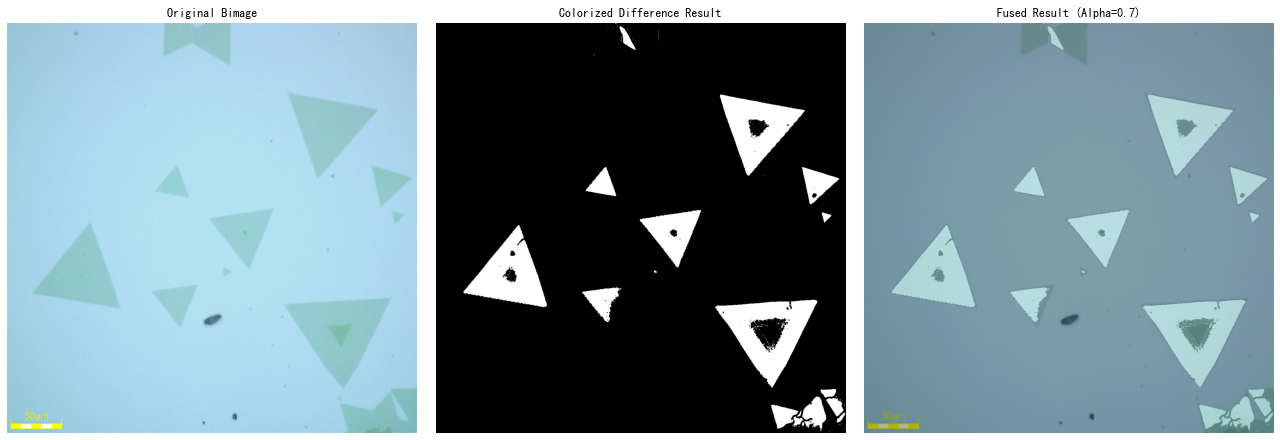

Fused result saved to: C:\Users\31227\Desktop\MoS2_Mask Rcnn\process_result\subtracted_overlay\2_subtracted_overlay.jpg


In [13]:
def blend_subtracted_with_abc_single(subtracted_path, abc_dir, output_dir):
    """Processing Fusion for a Single Image"""
    os.makedirs(output_dir, exist_ok=True)
    filename = os.path.basename(subtracted_path)
    base_name = filename.replace("_subtracted.png", "")
    
    abc_image_path = os.path.join(abc_dir, f"{base_name}.jpeg")
    if not os.path.exists(abc_image_path):
        raise FileNotFoundError(f"Error: Corresponding image not found in 'Bimage' directory: {abc_image_path}")
    
    subtracted_img = cv2.imread(subtracted_path, cv2.IMREAD_GRAYSCALE)
    abc_img = cv2.imread(abc_image_path)
    
    if abc_img.shape[:2] != subtracted_img.shape:
        print(f"Resizing Bimage: {abc_img.shape[:2]} -> {subtracted_img.shape}")
        abc_img = cv2.resize(abc_img, (subtracted_img.shape[1], subtracted_img.shape[0]))
    
    def blend_images(img1, img2, alpha=0.5):
        """Alpha Blending of Two Images"""
        return cv2.addWeighted(img1, alpha, img2, 1 - alpha, 0)
    
    subtracted_color = cv2.cvtColor(subtracted_img, cv2.COLOR_GRAY2BGR)
    blended_result = blend_images(abc_img, subtracted_color, alpha=0.7)
    
    output_path = os.path.join(output_dir, f"{base_name}_subtracted_overlay.jpg")
    cv2.imwrite(output_path, blended_result)
    return blended_result, abc_img, subtracted_color

# Executing Image Fusion
subtracted_overlay_dir = os.path.join(OUTPUT_DIR, "subtracted_overlay")
subtracted_path = os.path.join(subtracted_dir, f"{filename}_subtracted.png")
blended_result, abc_img, subtracted_color = blend_subtracted_with_abc_single(subtracted_path, ABC_DIR, subtracted_overlay_dir)

# Displaying the Fusion Results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cv2.cvtColor(abc_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Bimage")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(subtracted_color, cv2.COLOR_BGR2RGB))
axes[1].set_title("Colorized Difference Result")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(blended_result, cv2.COLOR_BGR2RGB))
axes[2].set_title("Fused Result (Alpha=0.7)")
axes[2].axis("off")

plt.tight_layout()
plt.show()
print(f"Fused result saved to: {os.path.join(subtracted_overlay_dir, f'{filename}_subtracted_overlay.jpg')}")